In [1]:
import numpy as np
import sys
sys.path.insert(0, '../src/')
from oz import PyOZ
import matplotlib.pyplot as plt
import torch

Defining the hard-spheres pair potential

In [2]:
def uhs(r,params):
    sigma = params
    return torch.where(r <= sigma, torch.tensor(float('inf')), torch.tensor(0.0))


In [3]:
sigma = 1.0

In [4]:
dr = 0.01

Creating the class PyOZ for HNC and PY

In [5]:
ljHNC = PyOZ(uhs,params=sigma,closure='HNC')
ljPY = PyOZ(uhs,params=sigma,closure='PY')

In [9]:
gHNC = []
gPY = []

rhobarray = np.arange(0.2,1.0,0.1)
kT = 1.0

for rhob in rhobarray:

    r, h, c = ljHNC.solve(rho=rhob, kBT=kT, rmax = 5.0, dr=dr)
    gHNC.append(h + 1.0)

    r, h, c = ljPY.solve(rho=rhob, kBT=kT, rmax = 5.0, dr=dr)
    gPY.append(h + 1.0)

Comparing with MC data from Barker 1971

In [7]:
import pandas as pd
MCdata = pd.read_excel('data/MCdata-radialdistribution-hardsphere-Barker1971.xls',sheet_name='radialdistributionfunction')

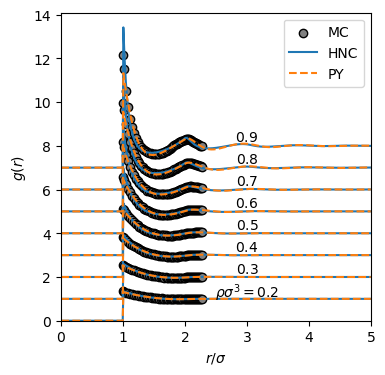

In [18]:
fig = plt.figure(figsize=(4,4))

for i, rhob in enumerate(rhobarray):
    if i==0:
        plt.scatter(MCdata['r'],MCdata[f'rhob={rhob:.1f}'],marker='o',edgecolors='k',facecolors='grey',label='MC')
    else:
        plt.scatter(MCdata['r'],MCdata[f'rhob={rhob:.1f}']+i,marker='o',edgecolors='k',facecolors='grey')

# Plotting the radial distribution functions from HNC and PY closures
for i, rhob in enumerate(rhobarray):
    if i==0:
        plt.plot(r,gHNC[i],'-',color='C0',label='HNC')
        plt.plot(r,gPY[i],'--',color='C1',label='PY')
        plt.text(3,1.1,rf'$\rho \sigma^3 = {rhob:.1f}$',ha='center')
    else:
        plt.plot(r,gHNC[i]+i,'-',color='C0')
        plt.plot(r,gPY[i]+i,'--',color='C1')
        plt.text(3,1.2+i,rf'${rhob:.1f}$',ha='center')
plt.xlim(0,5)
plt.ylim(0,None)
plt.legend(loc='best')
plt.xlabel(r'$r/\sigma$')
plt.ylabel(r'$g(r)$')

plt.savefig('radialdistributionfunction-hardspheres.png',dpi=200)


## Calculating contact value 

From Carnaghan-Starling EoS we have
$$g(\sigma) = \frac{1-0.5\eta}{(1-\eta)^3}$$
where $\eta=\rho \sigma^3/6$ is the packing fraction.

In [20]:
rhobarray = np.arange(0.01,1.1,0.05)
etaarray = (np.pi/6)*rhobarray

In [21]:
gsigmaHNC = []
gsigmaPY = []

dr = 0.001

for rhob in rhobarray:
    r, h, c = ljHNC.solve(rho=rhob, kBT=kT, rmax = 5.0, dr=dr)
    hsigma = h[r == 1.0+0.5*dr]
    gsigmaHNC.append(hsigma + 1.0)

    r, h, c = ljPY.solve(rho=rhob, kBT=kT, rmax = 5.0, dr=dr)
    hsigma = h[r == 1.0+0.5*dr]
    gsigmaPY.append(hsigma + 1.0)

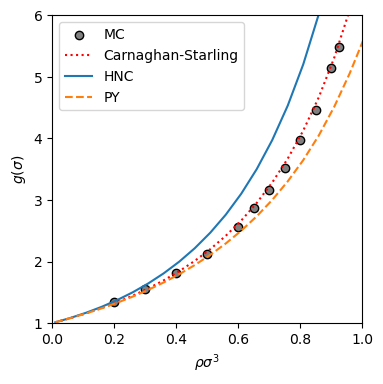

In [22]:
fig = plt.figure(figsize=(4,4))

# Contact Value from MC data
MCdata = pd.read_excel('data/MCdata-radialdistribution-hardsphere-Barker1971.xls',sheet_name='radialdistributionfunction_atsigma')
plt.scatter(MCdata['rhob'],MCdata['g(sigma)'],marker='o',edgecolors='k',facecolors='grey',label='MC')

# Contact value from CS EoS
gCS =  (1-0.5*etaarray)/(1-etaarray)**3
plt.plot(rhobarray,gCS,':',color='r',label='Carnaghan-Starling')

# Contact value from HNC and PY closures
plt.plot(rhobarray,gsigmaHNC,'-C0',label='HNC')
plt.plot(rhobarray,gsigmaPY,'--C1',label='PY')


plt.legend(loc='best')
plt.xlabel(r'$\rho \sigma^3$')
plt.ylabel(r'$g(\sigma)$')
plt.xlim(0.0,1.0)
plt.ylim(1,6.0)
plt.savefig('contactvalue-rdf-hardspheres.png',dpi=200)